# PROYECTO FINAL

### 0. Librerias

In [8]:
pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
pip install scikit-learn matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import pickle, base64, requests, os

# Librerías necesarias
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns


### 1. Dataset

In [53]:
excel=pd.read_excel('C:\\ER\\ML1\\archive\\Online Retail.xlsx')

In [ ]:
##lo neceitamos en csv par subirlo al Github
# excel.to_csv('online_retail.csv', index=False)
# # df=pd.read_csv('online_retail.csv')

In [54]:
df=excel.copy()

In [55]:
# Exploración inicial
print(df.head())
print(df.info())


  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----

### 2. Preparación Data

In [56]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [57]:
df = df.drop(columns=["Description"])
df.dropna(inplace = True)


In [58]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [60]:
df.shape

(406829, 7)

In [64]:
df[df["Quantity"]<0].head()


,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [ ]:
df["Total"] = df["Quantity"] * df["UnitPrice"]

In [178]:
# df[~(df["InvoiceNo"].astype(str).str.isdigit())].head()

df["Cancel"] = (df["Quantity"]<0)
df["Cancel"] = ~(df["InvoiceNo"].astype(str).str.isdigit())

In [179]:
df

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total,Cancel
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,False
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False
2,536365,84406B,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,False
3,536365,84029G,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False
4,536365,84029E,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,False
541905,581587,22899,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,False
541906,581587,23254,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,False
541907,581587,23255,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,False


In [180]:
aggreg = df.groupby(["CustomerID", "InvoiceNo", "InvoiceDate", "Cancel"]).agg(
    InvoiceTotal = ("Total", "sum"),
    ProductCount = ("Total", "count")
).reset_index()

In [181]:
def calculateInvoices(CancellationValues):
    return CancellationValues.map({True: -1, False: 1}).sum()

lastInvoiceDate = aggreg[aggreg["Cancel"] == False]["InvoiceDate"].max()

def findTimeInterval(InvoiceDate):
    return lastInvoiceDate - InvoiceDate.max()

total_data = aggreg.groupby(["CustomerID"]).agg(
    CustomerInvoiceTotal = ("InvoiceTotal", "sum"),
    CustomerInvoiceCount = ("Cancel", calculateInvoices),
    TimeIntervalAfterLastInvoice = ("InvoiceDate", findTimeInterval)
).reset_index()

In [182]:

total_data["RecencyDays"] = total_data["TimeIntervalAfterLastInvoice"].dt.days

In [183]:
print(total_data.shape)
print(total_data.info())
print(total_data.describe())

(4372, 5)
<class 'pandas.DataFrame'>
RangeIndex: 4372 entries, 0 to 4371
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype          
---  ------                        --------------  -----          
 0   CustomerID                    4372 non-null   float64        
 1   CustomerInvoiceTotal          4372 non-null   float64        
 2   CustomerInvoiceCount          4372 non-null   int64          
 3   TimeIntervalAfterLastInvoice  4372 non-null   timedelta64[us]
 4   RecencyDays                   4372 non-null   int64          
dtypes: float64(2), int64(2), timedelta64[us](1)
memory usage: 170.9 KB
None
         CustomerID  CustomerInvoiceTotal  CustomerInvoiceCount  \
count   4372.000000           4372.000000           4372.000000   
mean   15299.677722           1898.459701              3.410567   
std     1722.390705           8219.345141              6.349358   
min    12346.000000          -4287.630000             -6.000000   
25%    13812.7

### 3.1 K-means 

Text(0.5, 0, 'Monetary')

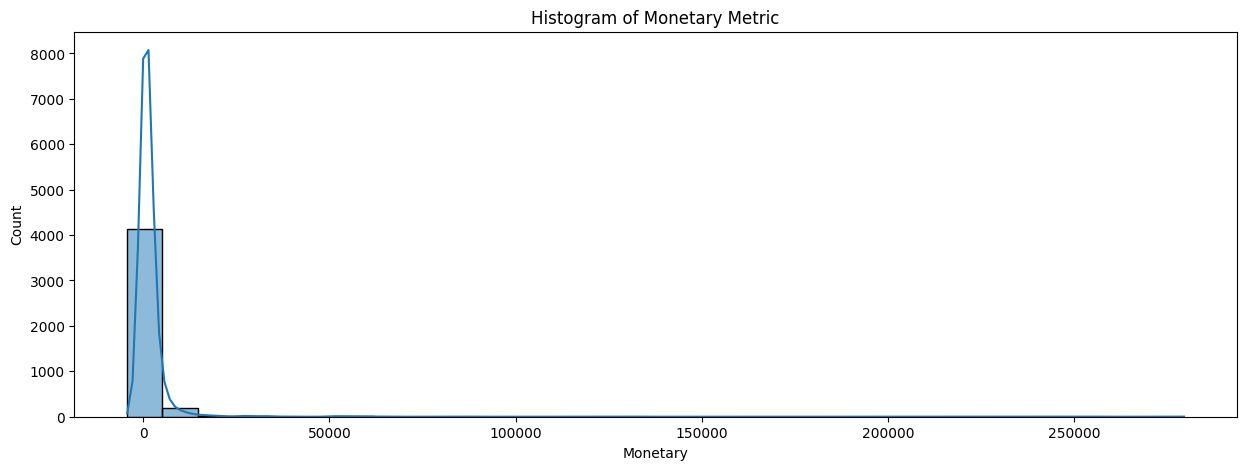

In [184]:

plt.figure(figsize=(15,5))
sns.histplot(total_data["CustomerInvoiceTotal"], kde=True, bins=30)
plt.title("Histogram of Monetary Metric")
plt.xlabel("Monetary")


Text(0.5, 0, 'Frequency')

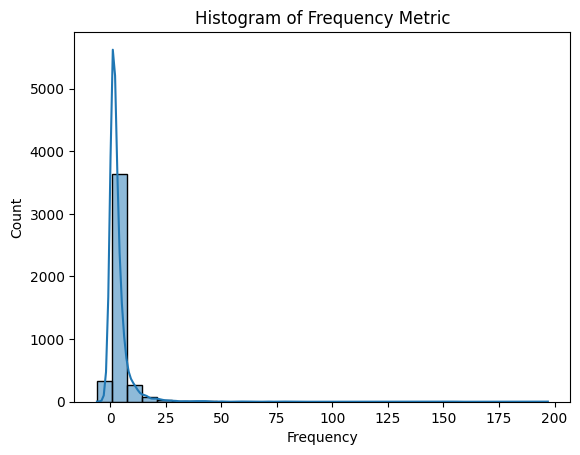

In [185]:
sns.histplot(total_data["CustomerInvoiceCount"], kde=True, bins=30)
plt.title("Histogram of Frequency Metric")
plt.xlabel("Frequency")


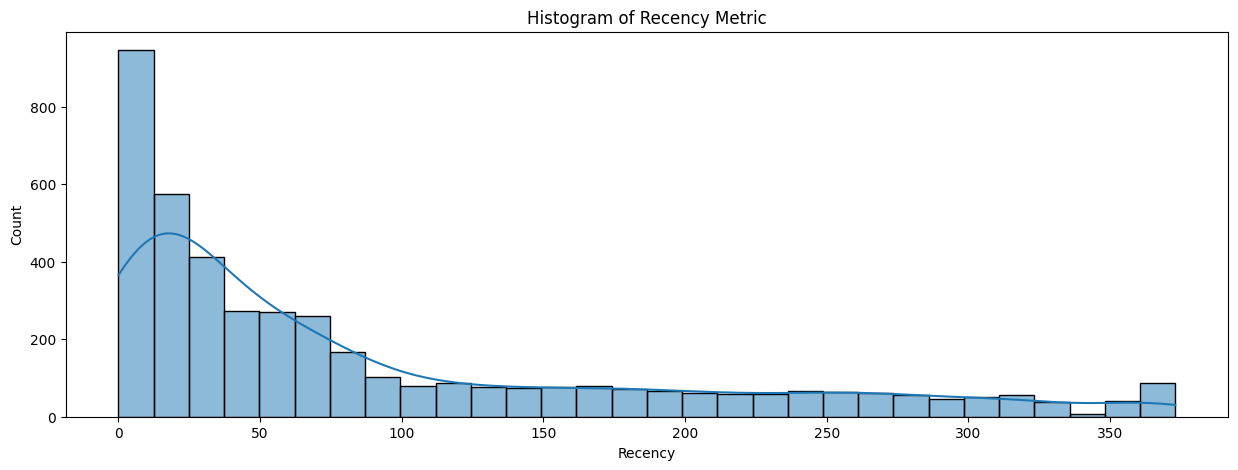

In [98]:
plt.figure(figsize=(15,5))
sns.histplot(total_data["RecencyDays"], kde=True, bins=30)
plt.title("Histogram of Recency Metric")
plt.xlabel("Recency")
plt.show()


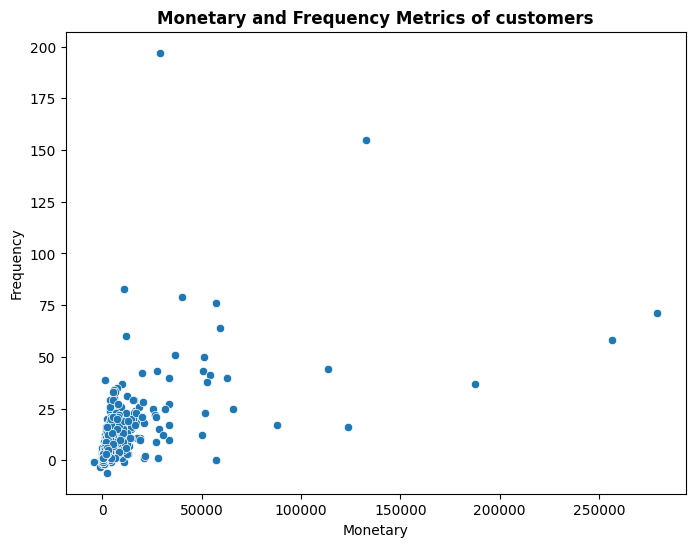

In [186]:
plt.figure(figsize = (8,6))
sns.scatterplot(data = total_data, x = "CustomerInvoiceTotal", y = "CustomerInvoiceCount")
plt.title("Monetary and Frequency Metrics of customers", fontweight="bold")
plt.xlabel("Monetary")
plt.ylabel("Frequency")
plt.show()

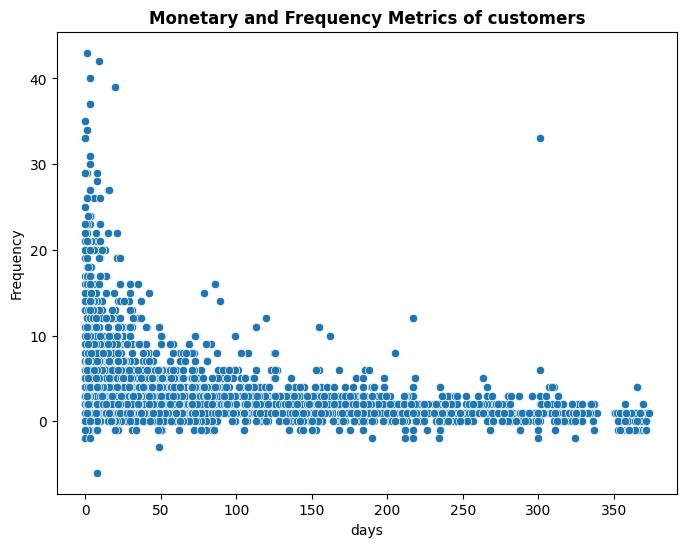

In [145]:
plt.figure(figsize = (8,6))
sns.scatterplot(data = total_data, x = "RecencyDays", y = "CustomerInvoiceCount")
plt.title("Monetary and Frequency Metrics of customers", fontweight="bold")
plt.xlabel("days")
plt.ylabel("Frequency")
plt.show()

In [187]:
total_data

,CustomerID,CustomerInvoiceTotal,CustomerInvoiceCount,TimeIntervalAfterLastInvoice,RecencyDays
0,12346.0,0.00,0,325 days 02:33:00,325
1,12347.0,4310.00,7,1 days 20:58:00,1
2,12348.0,1797.24,4,74 days 23:37:00,74
3,12349.0,1757.55,1,18 days 02:59:00,18
4,12350.0,334.40,1,309 days 20:49:00,309
...,...,...,...,...,...
4367,18280.0,180.60,1,277 days 02:58:00,277
4368,18281.0,80.82,1,180 days 01:57:00,180
4369,18282.0,176.60,1,7 days 01:07:00,7
4370,18283.0,2094.88,16,3 days 00:48:00,3


In [200]:

total_data = total_data[total_data["CustomerInvoiceTotal"] > 0]
total_data = total_data[total_data["CustomerInvoiceTotal"] < 15000]
total_data = total_data[total_data["CustomerInvoiceCount"] < 50]

In [201]:
total_data

,CustomerID,CustomerInvoiceTotal,CustomerInvoiceCount,TimeIntervalAfterLastInvoice,RecencyDays,Cluster
1,12347.0,4310.00,7,1 days 20:58:00,1,0
2,12348.0,1797.24,4,74 days 23:37:00,74,1
3,12349.0,1757.55,1,18 days 02:59:00,18,1
4,12350.0,334.40,1,309 days 20:49:00,309,1
5,12352.0,1545.41,5,35 days 22:13:00,35,1
...,...,...,...,...,...,...
4367,18280.0,180.60,1,277 days 02:58:00,277,1
4368,18281.0,80.82,1,180 days 01:57:00,180,1
4369,18282.0,176.60,1,7 days 01:07:00,7,1
4370,18283.0,2094.88,16,3 days 00:48:00,3,1


In [212]:

from sklearn.preprocessing import StandardScaler

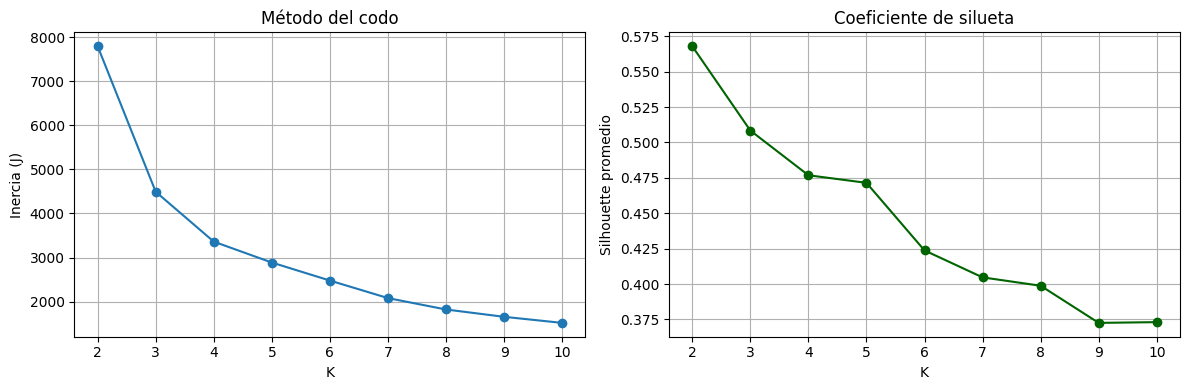

K con mayor silueta: K=2
[]


In [213]:

X_tot = total_data[["CustomerInvoiceTotal", "CustomerInvoiceCount", "RecencyDays"]]
scaler = StandardScaler()
X = scaler.fit_transform(X_tot[["CustomerInvoiceTotal","CustomerInvoiceCount","RecencyDays"]])

Ks = range(2, 11)
inercias, siluetas = [], []
for k in Ks:
    m = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    inercias.append(m.inertia_)
    siluetas.append(silhouette_score(X, m.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(Ks, inercias, marker='o')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inercia (J)')
axes[0].set_title('Método del codo')
axes[0].grid(True)

axes[1].plot(Ks, siluetas, marker='o', color='darkgreen')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette promedio')
axes[1].set_title('Coeficiente de silueta')
axes[1].grid(True)
plt.tight_layout(); plt.show()

print(f'K con mayor silueta: K={Ks[int(np.argmax(siluetas))]}')
print(siluetas[1:1])


In [ ]:

final_model = KMeans(n_clusters=2, random_state=42)


In [204]:

total_data["Cluster"] = final_model.fit_predict(X)

In [214]:
summary = total_data.groupby("Cluster").agg(
    CustomerCount = ("CustomerID", "count"),
    AverageTotalAmount = ("CustomerInvoiceTotal", "mean"),
    AverageInvoiceCount = ("CustomerInvoiceCount", "mean"),
    AverageRecency = ("RecencyDays", "mean")
).reset_index()



summary = summary.rename(columns={
    "Label": "Cluster",
    "CustomerCount": "Customer Count",
    "AverageTotalAmount": "Mean Monetary",
    "AverageInvoiceCount": "Mean Frequency",
    "AverageRecency": "Mean Recency"
})

summary = summary.round(2)

summary.head()

,Cluster,Customer Count,Mean Monetary,Mean Frequency,Mean Recency
0,0,3853,839.11,2.36,97.48
1,1,410,5880.57,9.53,24.20


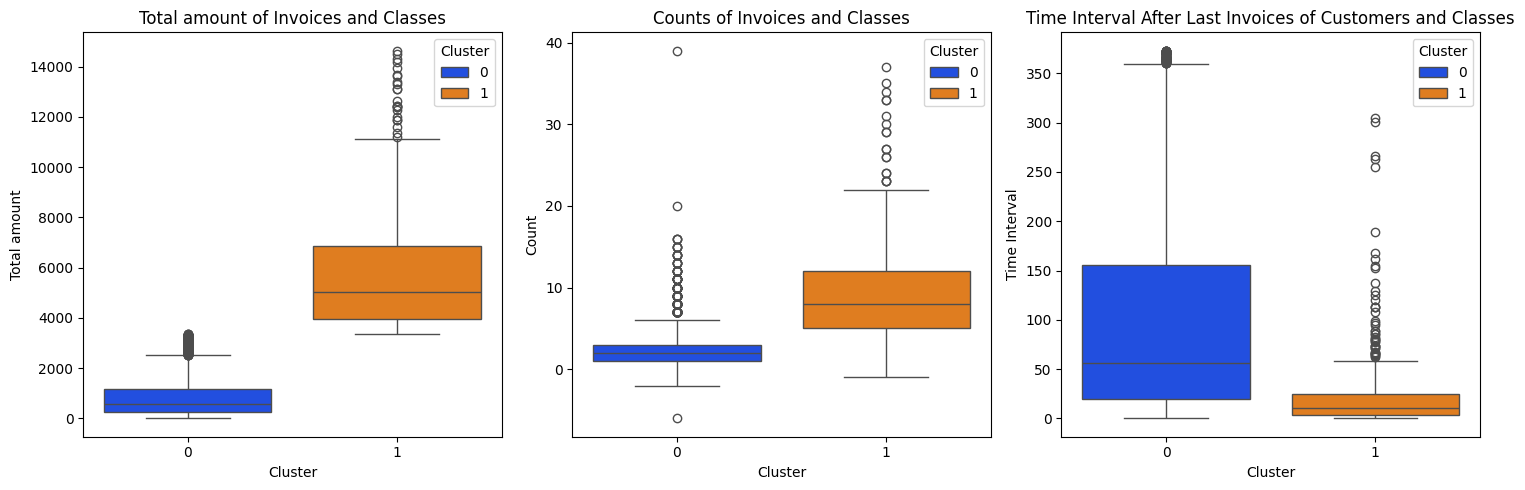

In [215]:
fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (15,5))

plt.subplot(1,3,1)
sns.boxplot(data = total_data, x = "Cluster", y = "CustomerInvoiceTotal", hue = "Cluster", palette = "bright")
plt.title("Total amount of Invoices and Classes")
plt.ylabel("Total amount")
plt.subplot(1,3,2)
sns.boxplot(data = total_data, x = "Cluster", y = "CustomerInvoiceCount", hue = "Cluster", palette = "bright")
plt.title("Counts of Invoices and Classes")
plt.ylabel("Count")
plt.subplot(1,3,3)
sns.boxplot(data = total_data, x = "Cluster", y = "RecencyDays", hue = "Cluster", palette = "bright")
plt.title("Time Interval After Last Invoices of Customers and Classes")
plt.ylabel("Time Interval")
plt.tight_layout()
plt.show()


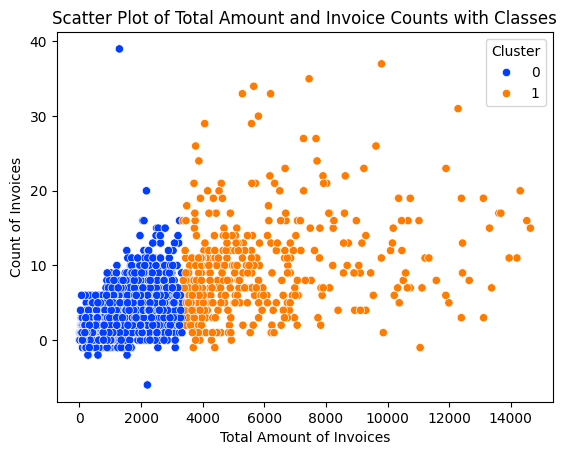

In [207]:
sns.scatterplot(data = total_data, x = "CustomerInvoiceTotal", y = "CustomerInvoiceCount", hue = "Cluster", palette = "bright")
plt.title("Scatter Plot of Total Amount and Invoice Counts with Classes")
plt.xlabel("Total Amount of Invoices")
plt.ylabel("Count of Invoices")
plt.show()

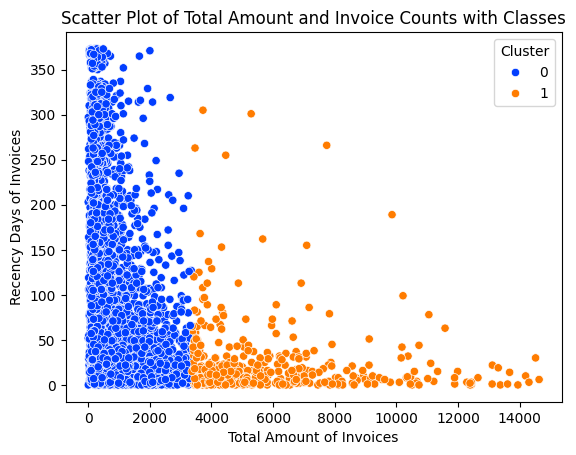

In [210]:
sns.scatterplot(data = total_data, x = "CustomerInvoiceTotal", y = "RecencyDays", hue = "Cluster", palette = "bright")
plt.title("Scatter Plot of Total Amount and Invoice Counts with Classes")
plt.xlabel("Total Amount of Invoices")
plt.ylabel("Recency Days of Invoices")
plt.show()

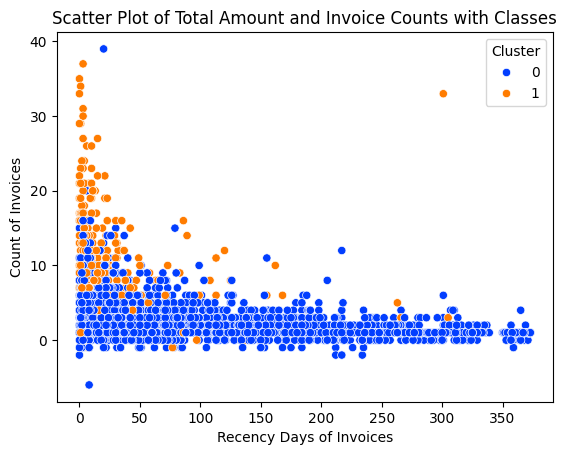

In [211]:
sns.scatterplot(data = total_data, x = "RecencyDays", y = "CustomerInvoiceCount", hue = "Cluster", palette = "bright")
plt.title("Scatter Plot of Total Amount and Invoice Counts with Classes")
plt.xlabel("Recency Days of Invoices")
plt.ylabel("Count of Invoices")
plt.show()

In [217]:
## guardamos pkl

with open("customer_segmentation_model.pkl", "wb") as file:
    pickle.dump(final_model, file)